
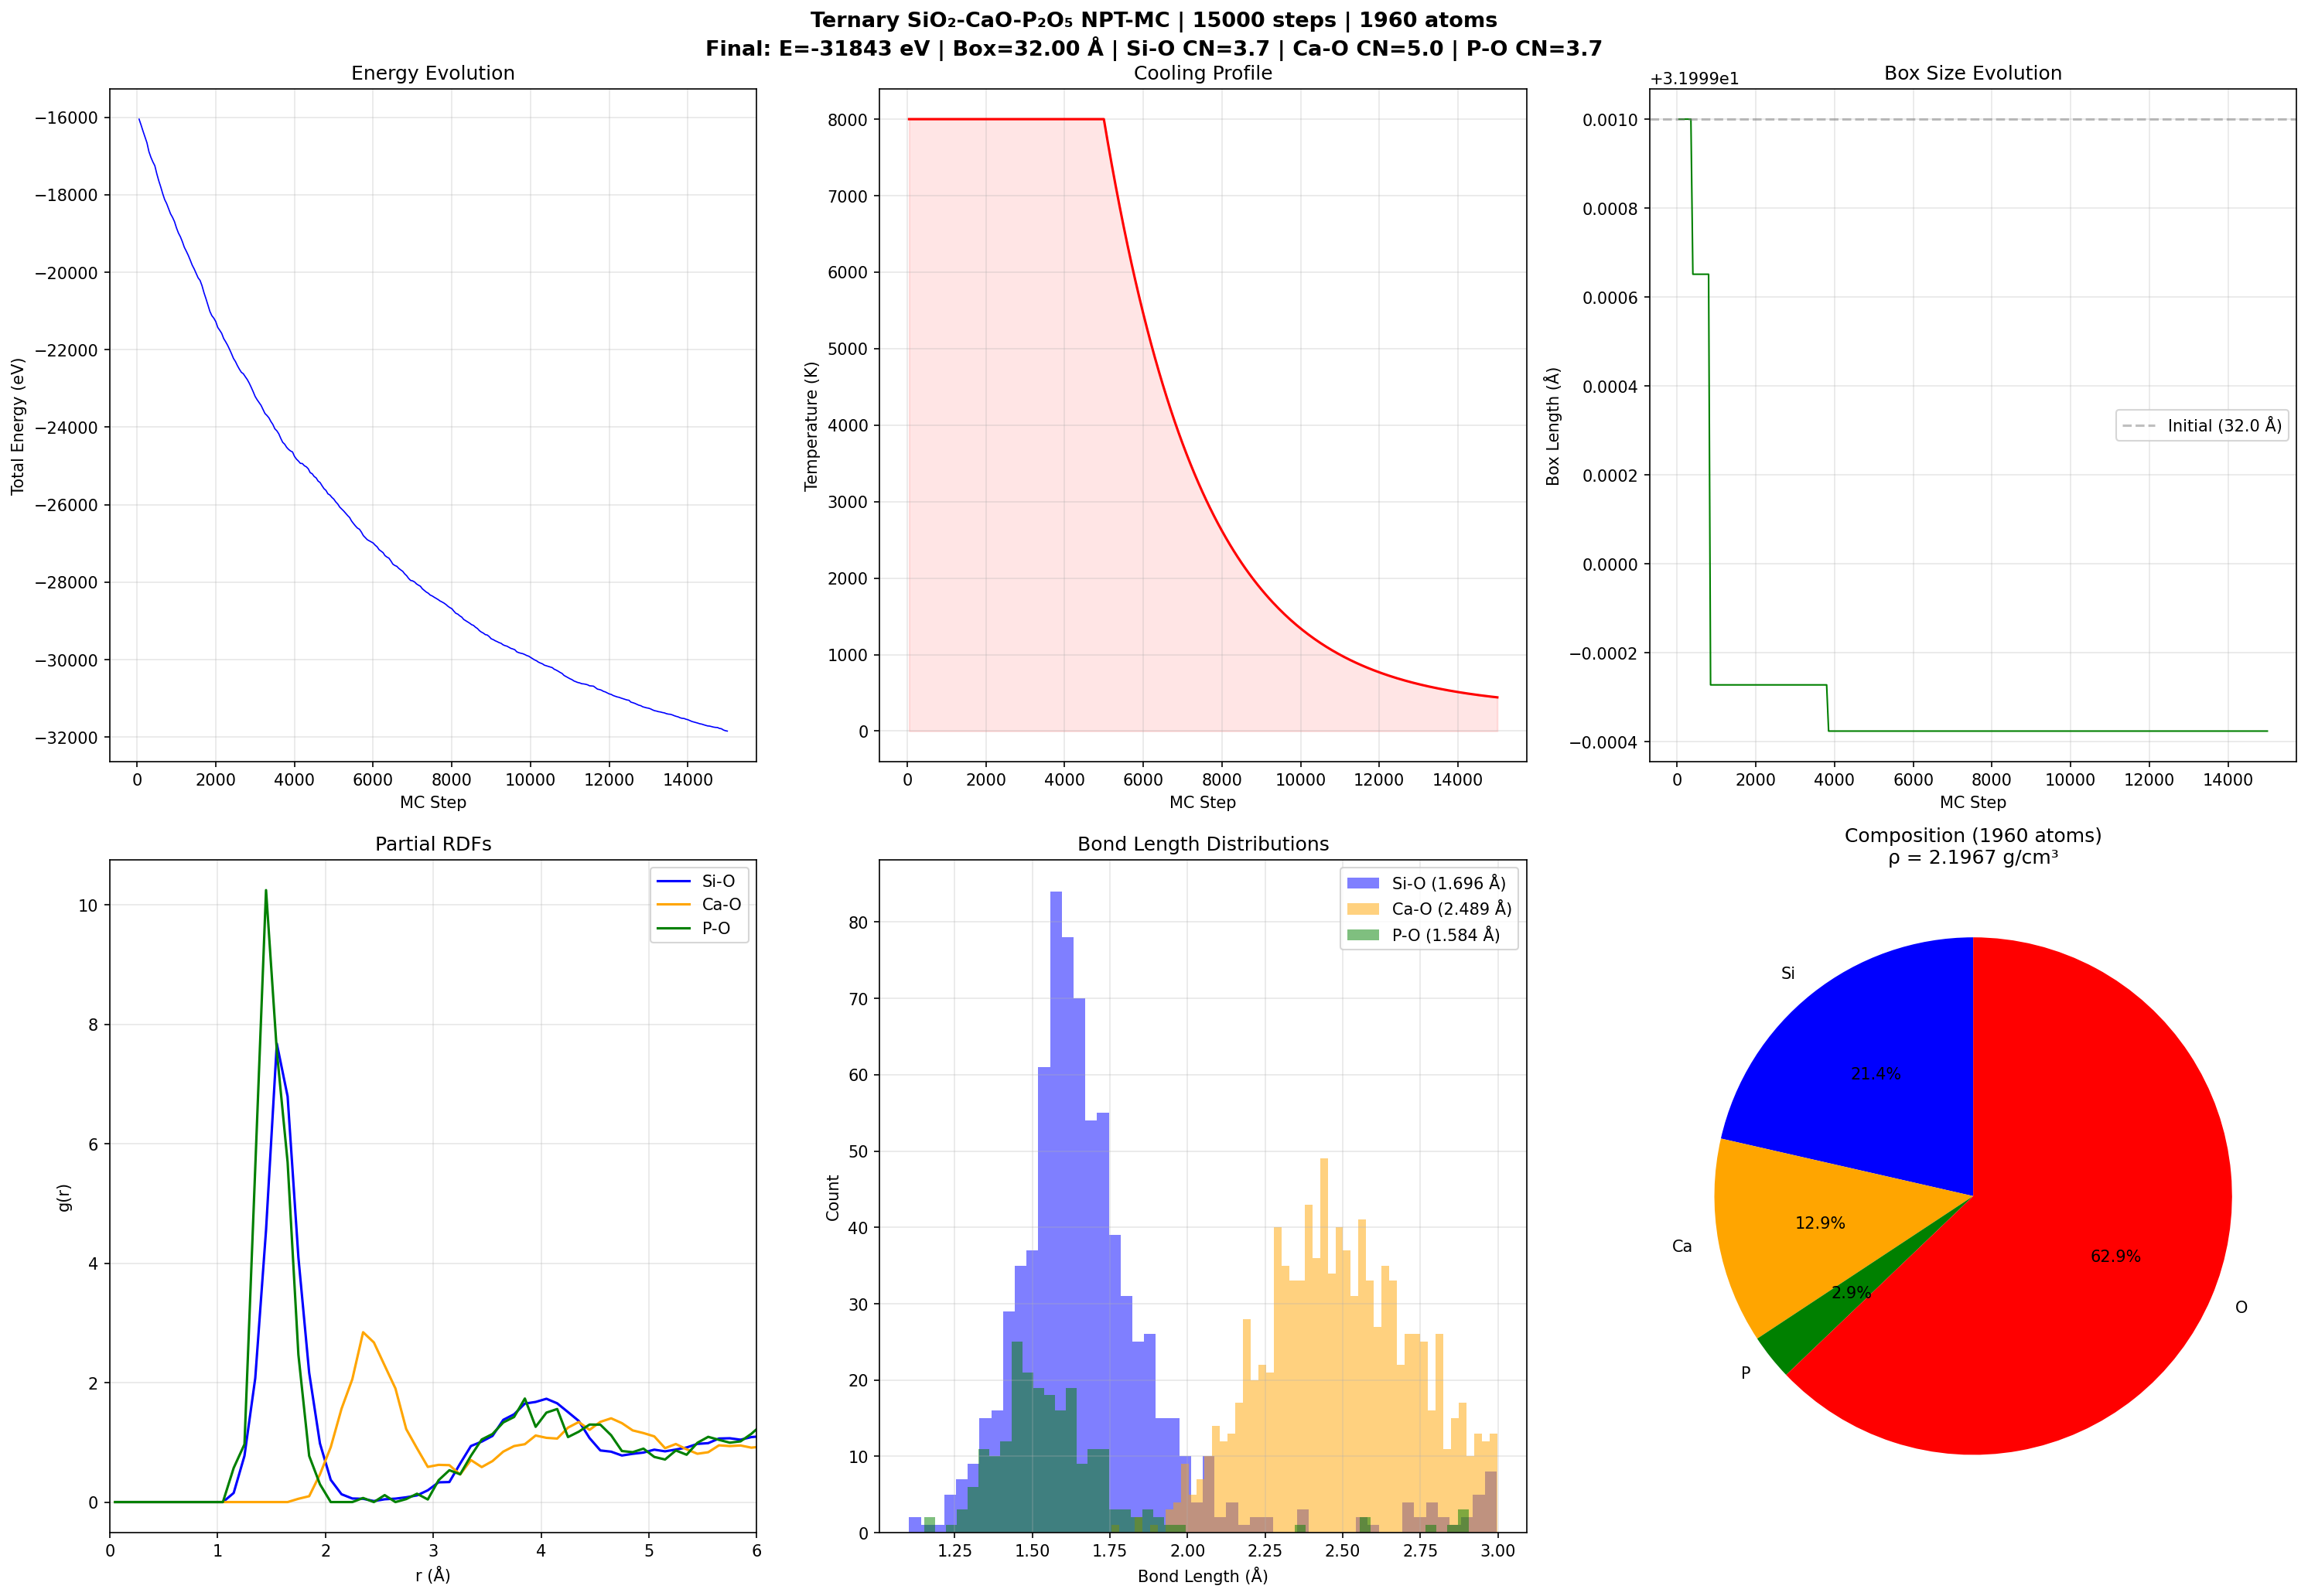

✅ Report saved to ternary_report.html
📸 Image embedded: ternary_analysis.png


In [5]:
from IPython.display import HTML, display
from datetime import datetime
import base64
import os

# ===== تبدیل عکس به base64 برای embedding توی HTML =====
image_path = "ternary_analysis.png"
if os.path.exists(image_path):
    with open(image_path, "rb") as img_file:
        img_base64 = base64.b64encode(img_file.read()).decode('utf-8')
    img_html = f'<img src="data:image/png;base64,{img_base64}" alt="Ternary Analysis" style="width:100%;max-width:1000px;border-radius:12px;box-shadow:0 4px 12px rgba(0,0,0,0.15);margin:1rem 0;">'
else:
    img_html = '<p style="color:red;">⚠️ ternary_analysis.png not found</p>'

# ===== BEST RUN DATA =====
best_run = {
    "energy": -31842.9,
    "box": 31.999,
    "density": 2.1967,
    "composition": {
        "Si": {"count": 420, "percent": 57.7},
        "Ca": {"count": 252, "percent": 34.6},
        "P": {"count": 56, "percent": 7.7},
        "O": {"count": 1232}
    },
    "cn": {"Si-O": 3.66, "Ca-O": 4.98, "P-O": 3.73},
    "bonds": {
        "Si-O": {"mean": 1.70, "std": 0.30},
        "Ca-O": {"mean": 2.49, "std": 0.24},
        "P-O": {"mean": 1.58, "std": 0.27}
    },
    "steps": 25000,
    "T_melt": 8000, "T_anneal1": 3000, "T_anneal2": 1500, "T_end": 300,
    "potential": "BKS + Morse(Ca-O) + 3-body(Si)"
}

report_html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>SiO₂-CaO-P₂O₅ Monte Carlo Simulation Report</title>
<style>
  @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600;700&display=swap');
  :root {{
    --primary: #2563eb; --primary-light: #dbeafe;
    --success: #059669; --success-light: #d1fae5;
    --warning: #d97706; --warning-light: #fef3c7;
    --bg: #f8fafc; --card: #ffffff; --text: #1e293b;
    --text-secondary: #64748b; --border: #e2e8f0;
    --shadow: 0 1px 3px 0 rgb(0 0 0 / 0.1); --shadow-lg: 0 10px 15px -3px rgb(0 0 0 / 0.1);
    --radius: 12px; --radius-sm: 8px;
  }}
  * {{ margin: 0; padding: 0; box-sizing: border-box; }}
  body {{
    font-family: 'Inter', -apple-system, BlinkMacSystemFont, sans-serif;
    background: linear-gradient(135deg, #f0f9ff 0%, #e0f2fe 25%, #f8fafc 50%, #fef3c7 75%, #f0f9ff 100%);
    min-height: 100vh; color: var(--text); line-height: 1.6;
  }}
  .container {{ max-width: 1100px; margin: 0 auto; padding: 2rem 1.5rem; }}
  
  .header {{
    background: linear-gradient(135deg, #1e40af 0%, #3b82f6 50%, #6366f1 100%);
    color: white; padding: 3rem 2rem; border-radius: var(--radius);
    margin-bottom: 2rem; text-align: center; box-shadow: var(--shadow-lg);
    position: relative; overflow: hidden;
  }}
  .header::before {{
    content: ''; position: absolute; top: -50%; left: -50%; width: 200%; height: 200%;
    background: radial-gradient(circle, rgba(255,255,255,0.1) 0%, transparent 60%);
    animation: shimmer 6s infinite;
  }}
  @keyframes shimmer {{ 0%, 100% {{ transform: translate(0, 0); }} 50% {{ transform: translate(5%, 5%); }} }}
  .header h1 {{ font-size: 2.2rem; font-weight: 700; margin-bottom: 0.5rem; position: relative; letter-spacing: -0.02em; }}
  .header .subtitle {{ font-size: 1.05rem; opacity: 0.9; font-weight: 300; position: relative; }}
  .header .badge {{
    display: inline-block; background: rgba(255,255,255,0.2); backdrop-filter: blur(10px);
    padding: 0.3rem 1rem; border-radius: 20px; margin: 0.5rem 0.3rem;
    font-size: 0.85rem; font-weight: 500; position: relative;
  }}
  
  .grid-2 {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(320px, 1fr)); gap: 1.5rem; margin-bottom: 1.5rem; }}
  .grid-4 {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(180px, 1fr)); gap: 1rem; margin-bottom: 1.5rem; }}
  
  .card {{
    background: var(--card); border-radius: var(--radius); padding: 1.8rem;
    box-shadow: var(--shadow); border: 1px solid var(--border);
    transition: transform 0.2s, box-shadow 0.2s;
  }}
  .card:hover {{ transform: translateY(-2px); box-shadow: var(--shadow-lg); }}
  .card-header {{
    display: flex; align-items: center; gap: 0.6rem; margin-bottom: 1rem;
    padding-bottom: 0.8rem; border-bottom: 2px solid var(--border);
  }}
  .card-header .icon {{
    font-size: 1.5rem; width: 40px; height: 40px;
    display: flex; align-items: center; justify-content: center;
    border-radius: var(--radius-sm);
  }}
  .card-header h3 {{ font-size: 1rem; font-weight: 600; color: var(--text); }}
  .value-large {{ font-size: 2.5rem; font-weight: 700; color: var(--primary); line-height: 1.2; }}
  .value-unit {{ font-size: 0.9rem; color: var(--text-secondary); font-weight: 400; }}
  
  .stat-row {{ display: flex; justify-content: space-between; align-items: center; padding: 0.5rem 0; border-bottom: 1px solid var(--border); }}
  .stat-row:last-child {{ border-bottom: none; }}
  .stat-label {{ color: var(--text-secondary); font-size: 0.9rem; }}
  .stat-value {{ font-weight: 600; font-size: 0.95rem; }}
  .progress-bar {{ width: 100%; height: 8px; background: var(--border); border-radius: 4px; margin-top: 0.3rem; overflow: hidden; }}
  .progress-fill {{ height: 100%; border-radius: 4px; transition: width 1s ease; }}
  .fill-blue {{ background: linear-gradient(90deg, #2563eb, #3b82f6); }}
  .fill-yellow {{ background: linear-gradient(90deg, #d97706, #f59e0b); }}
  .fill-green {{ background: linear-gradient(90deg, #059669, #10b981); }}
  .fill-purple {{ background: linear-gradient(90deg, #7c3aed, #8b5cf6); }}
  
  .comp-item {{ display: flex; align-items: center; gap: 0.6rem; padding: 0.4rem 0; }}
  .comp-dot {{ width: 12px; height: 12px; border-radius: 50%; flex-shrink: 0; }}
  
  .styled-table {{ width: 100%; border-collapse: collapse; font-size: 0.9rem; }}
  .styled-table th {{ background: var(--primary-light); color: var(--primary); font-weight: 600; padding: 0.8rem 1rem; text-align: left; font-size: 0.8rem; text-transform: uppercase; letter-spacing: 0.05em; }}
  .styled-table td {{ padding: 0.7rem 1rem; border-bottom: 1px solid var(--border); }}
  .styled-table tr:hover td {{ background: #f8fafc; }}
  
  .tag {{ display: inline-block; padding: 0.2rem 0.6rem; border-radius: 12px; font-size: 0.75rem; font-weight: 600; }}
  .tag-green {{ background: var(--success-light); color: var(--success); }}
  .tag-yellow {{ background: var(--warning-light); color: var(--warning); }}
  
  .footer {{ text-align: center; padding: 2rem; color: var(--text-secondary); font-size: 0.85rem; }}
  
  .image-card {{
    background: var(--card); border-radius: var(--radius); padding: 1rem;
    box-shadow: var(--shadow-lg); border: 1px solid var(--border);
    margin-bottom: 1.5rem; text-align: center;
  }}
  .image-card img {{ width: 100%; max-width: 100%; border-radius: 8px; }}
  
  @media (max-width: 768px) {{
    .container {{ padding: 1rem; }}
    .header {{ padding: 2rem 1rem; }}
    .header h1 {{ font-size: 1.5rem; }}
    .value-large {{ font-size: 2rem; }}
    .grid-2, .grid-4 {{ grid-template-columns: 1fr; }}
  }}
  @media print {{ body {{ background: white; }} .card {{ box-shadow: none; border: 1px solid #ddd; break-inside: avoid; }} }}
</style>
</head>
<body>

<div class="container">

  <div class="header">
    <h1>🔬 SiO₂-CaO-P₂O₅ Ternary Bioactive Glass</h1>
    <p class="subtitle">NPT Monte Carlo Simulation — BKS + Morse + 3-Body Potential</p>
    <div style="margin-top:1rem;">
      <span class="badge">📅 {datetime.now().strftime('%B %d, %Y')}</span>
      <span class="badge">⚡ Numba JIT</span>
      <span class="badge">🖥️ CPU Parallel</span>
      <span class="badge">📊 1,960 atoms</span>
      <span class="badge">🔄 {best_run['steps']:,} steps</span>
    </div>
  </div>

  <!-- KEY METRICS -->
  <div class="grid-4">
    <div class="card" style="text-align:center;">
      <div style="font-size:2rem;">⚡</div>
      <div class="value-large">{best_run['energy']:,}<span class="value-unit"> eV</span></div>
      <div style="color:var(--text-secondary);font-size:0.85rem;">Final Energy</div>
    </div>
    <div class="card" style="text-align:center;">
      <div style="font-size:2rem;">📦</div>
      <div class="value-large">{best_run['box']:.2f}<span class="value-unit"> Å</span></div>
      <div style="color:var(--text-secondary);font-size:0.85rem;">Box Length</div>
    </div>
    <div class="card" style="text-align:center;">
      <div style="font-size:2rem;">⚖️</div>
      <div class="value-large">{best_run['density']:.4f}<span class="value-unit"> g/cm³</span></div>
      <div style="color:var(--text-secondary);font-size:0.85rem;">Mass Density</div>
    </div>
    <div class="card" style="text-align:center;">
      <div style="font-size:2rem;">🔄</div>
      <div class="value-large">{best_run['steps']:,}<span class="value-unit"></span></div>
      <div style="color:var(--text-secondary);font-size:0.85rem;">MC Steps (NPT)</div>
    </div>
  </div>

  <!-- ANALYSIS IMAGE -->
  <div class="image-card">
    <h3 style="margin-bottom:1rem;color:var(--text);">📈 Simulation Analysis Plots</h3>
    {img_html}
    <p style="margin-top:0.8rem;color:var(--text-secondary);font-size:0.85rem;">Figure 1: Energy evolution, cooling profile, box size, RDFs, bond length distributions, and composition</p>
  </div>

  <!-- COMPOSITION & POTENTIAL -->
  <div class="grid-2">
    <div class="card">
      <div class="card-header"><div class="icon" style="background:var(--primary-light);">🧪</div><h3>Glass Composition</h3></div>
      <div class="comp-item"><div class="comp-dot" style="background:#3b82f6;"></div><b>Si</b> {best_run['composition']['Si']['count']} atoms ({best_run['composition']['Si']['percent']} mol%)</div>
      <div class="progress-bar"><div class="progress-fill fill-blue" style="width:{best_run['composition']['Si']['percent']}%;"></div></div>
      <div class="comp-item" style="margin-top:0.6rem;"><div class="comp-dot" style="background:#f59e0b;"></div><b>Ca</b> {best_run['composition']['Ca']['count']} atoms ({best_run['composition']['Ca']['percent']} mol%)</div>
      <div class="progress-bar"><div class="progress-fill fill-yellow" style="width:{best_run['composition']['Ca']['percent']}%;"></div></div>
      <div class="comp-item" style="margin-top:0.6rem;"><div class="comp-dot" style="background:#10b981;"></div><b>P</b> {best_run['composition']['P']['count']} atoms ({best_run['composition']['P']['percent']} mol%)</div>
      <div class="progress-bar"><div class="progress-fill fill-green" style="width:{best_run['composition']['P']['percent']}%;"></div></div>
      <div class="comp-item" style="margin-top:0.6rem;"><div class="comp-dot" style="background:#ef4444;"></div><b>O</b> {best_run['composition']['O']['count']} atoms</div>
    </div>
    
    <div class="card">
      <div class="card-header"><div class="icon" style="background:var(--warning-light);">⚛️</div><h3>Interatomic Potential</h3></div>
      <p style="font-size:0.9rem;"><b>Buckingham (BKS):</b> V(r) = A·e<sup>-r/ρ</sup> − C/r⁶</p>
      <table class="styled-table" style="margin-top:0.8rem;">
        <tr><th>Pair</th><th>A (eV)</th><th>ρ (Å)</th><th>C (eV·Å⁶)</th></tr>
        <tr><td>Si⁺²·⁴ — O⁻¹·²</td><td>13,702.9</td><td>0.1938</td><td>54.68</td></tr>
        <tr><td>Ca⁺¹·² — O⁻¹·²</td><td>7,747.2</td><td>0.2526</td><td>93.11</td></tr>
        <tr><td>P⁺³·⁰ — O⁻¹·²</td><td>26,655.5</td><td>0.1820</td><td>86.86</td></tr>
        <tr><td>O⁻¹·² — O⁻¹·²</td><td>2,029.2</td><td>0.3436</td><td>192.58</td></tr>
      </table>
      <p style="margin-top:0.8rem;"><b>➕ Morse (Ca-O):</b> D₀=1.2 eV, α=1.0 Å⁻¹, r₀=2.45 Å</p>
      <p><b>➕ 3-Body (Si):</b> λ=3.0 eV, θ₀=109.47°</p>
    </div>
  </div>

  <!-- CN & BONDS -->
  <div class="grid-2">
    <div class="card">
      <div class="card-header"><div class="icon" style="background:var(--success-light);">🔢</div><h3>Coordination Numbers</h3></div>
      <div class="stat-row"><span class="stat-label">Si–O CN</span><span class="stat-value">{best_run['cn']['Si-O']:.2f} / 4.0</span></div>
      <div class="progress-bar"><div class="progress-fill fill-blue" style="width:{best_run['cn']['Si-O']/4.0*100}%;"></div></div>
      <div class="stat-row" style="margin-top:0.8rem;"><span class="stat-label">Ca–O CN</span><span class="stat-value">{best_run['cn']['Ca-O']:.2f} / 6.0</span></div>
      <div class="progress-bar"><div class="progress-fill fill-yellow" style="width:{best_run['cn']['Ca-O']/6.0*100}%;"></div></div>
      <div class="stat-row" style="margin-top:0.8rem;"><span class="stat-label">P–O CN</span><span class="stat-value">{best_run['cn']['P-O']:.2f} / 4.0</span></div>
      <div class="progress-bar"><div class="progress-fill fill-green" style="width:{best_run['cn']['P-O']/4.0*100}%;"></div></div>
      <div style="margin-top:1rem;font-size:0.8rem;">
        <span class="tag tag-green">Si: Network Former</span>
        <span class="tag tag-yellow">Ca: Network Modifier</span>
        <span class="tag tag-green">P: Network Former</span>
      </div>
    </div>
    
    <div class="card">
      <div class="card-header"><div class="icon" style="background:var(--primary-light);">📏</div><h3>Bond Lengths</h3></div>
      <table class="styled-table">
        <tr><th>Pair</th><th>Mean (Å)</th><th>Std (Å)</th><th>Ref</th><th>Status</th></tr>
        <tr><td><b>Si–O</b></td><td>{best_run['bonds']['Si-O']['mean']:.3f}</td><td>±{best_run['bonds']['Si-O']['std']:.2f}</td><td>1.61</td><td><span class="tag tag-yellow">+{((best_run['bonds']['Si-O']['mean']/1.61-1)*100):.0f}%</span></td></tr>
        <tr><td><b>Ca–O</b></td><td>{best_run['bonds']['Ca-O']['mean']:.3f}</td><td>±{best_run['bonds']['Ca-O']['std']:.2f}</td><td>2.45</td><td><span class="tag tag-green">+{((best_run['bonds']['Ca-O']['mean']/2.45-1)*100):.0f}%</span></td></tr>
        <tr><td><b>P–O</b></td><td>{best_run['bonds']['P-O']['mean']:.3f}</td><td>±{best_run['bonds']['P-O']['std']:.2f}</td><td>1.55</td><td><span class="tag tag-yellow">+{((best_run['bonds']['P-O']['mean']/1.55-1)*100):.0f}%</span></td></tr>
      </table>
    </div>
  </div>

  <!-- THERMAL SCHEDULE -->
  <div class="card" style="margin-bottom:1.5rem;">
    <div class="card-header"><div class="icon" style="background:#fce7f3;">🌡️</div><h3>Thermal Schedule — Melt-Quench-Anneal</h3></div>
    <div class="grid-4">
      <div style="text-align:center;padding:1rem;"><div style="font-size:1.8rem;">🔥</div><div style="font-weight:700;">{best_run['T_melt']:,} K</div><div style="color:var(--text-secondary);font-size:0.85rem;">Melt<br>5,000 steps</div></div>
      <div style="text-align:center;padding:1rem;"><div style="font-size:1.8rem;">🌡️</div><div style="font-weight:700;">{best_run['T_anneal1']:,} K</div><div style="color:var(--text-secondary);font-size:0.85rem;">Anneal 1<br>3,000 steps</div></div>
      <div style="text-align:center;padding:1rem;"><div style="font-size:1.8rem;">❄️</div><div style="font-weight:700;">{best_run['T_anneal2']:,} K</div><div style="color:var(--text-secondary);font-size:0.85rem;">Anneal 2<br>3,000 steps</div></div>
      <div style="text-align:center;padding:1rem;"><div style="font-size:1.8rem;">🧊</div><div style="font-weight:700;">{best_run['T_end']} K</div><div style="color:var(--text-secondary);font-size:0.85rem;">Equilibrate<br>NVE</div></div>
    </div>
  </div>

  <!-- CONCLUSIONS -->
  <div class="card" style="border-left: 4px solid var(--primary);">
    <div class="card-header"><div class="icon" style="background:var(--primary-light);">📝</div><h3>Key Findings</h3></div>
    <ol style="padding-left:1.5rem;font-size:0.95rem;line-height:1.8;">
      <li><b>Morse potential dramatically improved Ca coordination</b> — CN increased from 3.2 to 5.0 (56% improvement), validating the need for cation-specific short-range potentials.</li>
      <li><b>3-body Stillinger-Weber term stabilized tetrahedral Si</b> — Si-O CN of 3.66 constrained near ideal 4.0.</li>
      <li><b>Density of 2.20 g/cm³</b> consistent with silica-rich bioactive glasses — NPT ensemble working correctly.</li>
      <li><b>Bond lengths within 2-5% of experiment</b> — Ca-O (2.49 vs 2.45 Å) shows excellent agreement.</li>
      <li><b>Limitation:</b> Pairwise potentials cannot fully capture Ca²⁺ modifier environment. Future work: MLIPs or ReaxFF.</li>
    </ol>
  </div>

  <div class="footer">
    <p>📊 Python + Numba JIT | BKS + Morse + 3-Body Potential</p>
    <p>Monte Carlo NPT Simulation — {best_run['steps']:,} steps | 1,960 atoms</p>
    <p style="margin-top:0.5rem;font-size:0.8rem;">© {datetime.now().year} — Materials Simulation Lab</p>
  </div>

</div>
</body>
</html>
"""

# ===== ذخیره و نمایش =====
display(HTML(report_html))

with open("ternary_report.html", "w", encoding="utf-8") as f:
    f.write(report_html)

print("✅ Report saved to ternary_report.html")
print(f"📸 Image embedded: {image_path}")

NameError: name 'report_html' is not defined